In [1]:
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from sklearn import metrics

sys.path.append("../src")
from features.feature_engineering import main as import_data
from models.elo import ELO
from models.model_pipeline import main

# Helper Functions

In [ ]:
def betting_simulation(df: pd.DataFrame, threshold: float) -> tuple[int, int]:
    """
    Compute the number of bets placed and bets won given a threshold.

    Args:
        df: DataFrame containing columns 'model_predictions', 'home_line', 'result'.
        threshold: Threshold for deciding when to place a bet.

    Returns:
        tuple: (bets_placed, bets_won)
    """
    bets_placed = 0
    bets_won = 0
    for row in df.itertuples():
        if row.model_predictions + threshold < -row.home_line:
            bets_placed += 1
            if row.result < -row.home_line:
                bets_won += 1
        elif row.model_predictions > -row.home_line + threshold:
            bets_placed += 1
            if row.result > -row.home_line:
                bets_won += 1
    return bets_placed, bets_won


def sweep_thresholds(df: pd.DataFrame, start=0, stop=3.1, step=0.1) -> pd.DataFrame:
    """
    Sweep thresholds to calculate betting accuracy and number of bets placed.

    Args:
        df: Test DataFrame.
        start: Minimum threshold.
        stop: Maximum threshold.
        step: Step size.

    Returns:
        pd.DataFrame: DataFrame with columns: 'threshold', 'accuracy', 'bets_placed'.
    """
    results = []
    for threshold in np.arange(start, stop, step):
        bets_placed, bets_won = betting_simulation(df, threshold)
        accuracy = bets_won / bets_placed if bets_placed > 0 else np.nan
        results.append(
            {"threshold": threshold, "accuracy": accuracy, "bets_placed": bets_placed}
        )
    return pd.DataFrame(results)


def evaluate_model(df: pd.DataFrame) -> dict:
    """
    Compute standard regression metrics for model and Vegas line.

    Args:
        df: DataFrame containing 'result', 'model_predictions', and 'home_line'.

    Returns:
        dict: Dictionary of RMSE, MAE, R2 for model and Vegas line.
    """
    metrics_dict = {
        "model_rmse": metrics.root_mean_squared_error(
            df["result"], df["model_predictions"]
        ),
        "model_mae": metrics.mean_absolute_error(df["result"], df["model_predictions"]),
        "model_r2": metrics.r2_score(df["result"], df["model_predictions"]),
        "vegas_rmse": metrics.root_mean_squared_error(df["result"], -df["home_line"]),
        "vegas_mae": metrics.mean_absolute_error(df["result"], -df["home_line"]),
        "vegas_r2": metrics.r2_score(df["result"], -df["home_line"]),
    }
    return metrics_dict


def plot_pipeline_results(
    df: pd.DataFrame,
    results: pd.DataFrame,
    model,
    x_train: pd.DataFrame,
    shap_plot: bool,
):
    """
    Plot model evaluation results.

    Args:
        df: Test dataframe containing 'result', 'model_predictions', and 'home_line'.
        results: DataFrame from sweep_thresholds helper function.
        model: Trained model for SHAP analysis.
        x_train: Training feature matrix for SHAP computation.
        shap_plot: Whether or not to plot SHAP values.
    """
    # --- Threshold plots ---
    plt.figure(figsize=(8, 4))

    # Accuracy vs Threshold
    plt.subplot(1, 2, 1)
    plt.plot(results["threshold"], results["accuracy"])
    plt.xlabel("Model edge")
    plt.ylabel("Accuracy")
    plt.title("Betting Accuracy vs Threshold")

    # Bets placed vs Threshold
    plt.subplot(1, 2, 2)
    plt.plot(results["threshold"], results["bets_placed"])
    plt.xlabel("Model edge")
    plt.ylabel("Bets placed")
    plt.title("Bets Placed vs Threshold")

    plt.tight_layout()
    plt.show()

    # --- SHAP summary plot ---
    if shap_plot:
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(x_train)
        shap.summary_plot(
            shap_values,
            x_train,
            max_display=20,
            plot_type="violin",
            show=True,
            plot_size=[8, 6],
        )

# Import Data

In [3]:
features = [
    # "home_line",
    # "over_under",
    # "home_implied_score",
    # "away_implied_score",
    "week",
    "is_indoors",
    "surface",
    "attendance",
    "home_travel_distance",
    "away_travel_distance",
    "home_rest_days",
    "away_rest_days",
    "weather_windy",
    "weather_rainy",
    "weather_snow",
    "weather_severe",
    "temp",
    "wind_mph",
    "elo_diff",
    "home_ats_pctg_5",
    "away_ats_pctg_5",
    "home_ats_pctg_10",
    "away_ats_pctg_10",
    "home_ats_pctg_fav_5",
    "away_ats_pctg_fav_5",
    "home_ats_pctg_fav_10",
    "away_ats_pctg_fav_10",
    "home_ats_pctg_und_5",
    "away_ats_pctg_und_5",
    "home_ats_pctg_und_10",
    "away_ats_pctg_und_10",
    "home_win_pctg_5",
    "away_win_pctg_5",
    "home_win_pctg_10",
    "away_win_pctg_10",
    "home_spread_diff_5",
    "away_spread_diff_5",
    "home_spread_diff_10",
    "away_spread_diff_10",
    "epa_mean_adv_home",
    "epa_mean_adv_away",
    "pbp_exp_points_tot_adv_home",
    "pbp_exp_points_tot_adv_away",
    "pbp_exp_points_pass_adv_home",
    "pbp_exp_points_pass_adv_away",
    "pbp_exp_points_rush_adv_home",
    "pbp_exp_points_rush_adv_away",
    "pbp_exp_points_k_adv",
    "pbp_exp_points_p_adv",
    "pbp_exp_points_fgxp_adv",
    "pbp_exp_points_to_adv_home",
    "pbp_exp_points_to_adv_away",
    "final_score_adv_home",
    "final_score_adv_away",
    "yds_adv",
    "ydsnet_mean_adv_home",
    "ydsnet_mean_adv_away",
    "ydstogo_mean_adv_home",
    "ydstogo_mean_adv_away",
    "drive_nunique_adv_home",
    "drive_nunique_adv_away",
    "third_down_conversions_adv",
    "fourth_down_conversions_adv",
    "pass_yds_net_adv",
    "pass_attempts_adv",
    "pass_cmp_adv",
    "pass_tds_adv",
    "first_down_pass_sum_adv_home",
    "first_down_pass_sum_adv_away",
    "first_down_rush_sum_adv_home",
    "first_down_rush_sum_adv_away",
    "rush_attempts_adv",
    "rush_tds_adv",
    "receiving_yards_mean_adv_home",
    "receiving_yards_mean_adv_away",
    "yards_after_catch_mean_adv_home",
    "yards_after_catch_mean_adv_away",
    "sacks_adv",
    "sack_yards_adv",
    "tackled_for_loss_sum_adv_home",
    "tackled_for_loss_sum_adv_away",
    "fumbles_adv",
    "turnovers_adv",
    "penalties_adv"
]

In [4]:
historical_elos = pd.read_csv("../data/external/historical_elos.csv")
data = import_data(2010, 2024, span=5)
data = ELO(data, historical_elos).data
data["home_line_inverse"] = -data["home_line"]
data[["game_id"] + features].head()

,game_id,week,is_indoors,surface,attendance,home_travel_distance,away_travel_distance,home_rest_days,away_rest_days,weather_windy,...,receiving_yards_mean_adv_away,yards_after_catch_mean_adv_home,yards_after_catch_mean_adv_away,sacks_adv,sack_yards_adv,tackled_for_loss_sum_adv_home,tackled_for_loss_sum_adv_away,fumbles_adv,turnovers_adv,penalties_adv
0,20110911_atl_chi,1,0,0.0,62115.0,0.000000,585.372727,7,7,0,...,-0.204785,0.420038,-0.347207,1.161220,7.538126,0.501089,-0.278867,0.265795,0.472767,1.450980
1,20110911_cin_cle,1,0,0.0,67321.0,0.000000,308.257010,7,7,0,...,-0.648175,0.228779,-0.688121,0.333333,-0.291667,0.000000,0.833333,0.333333,-0.208333,-0.500000
2,20110911_car_crd,1,1,0.0,60627.0,639.618542,1598.361423,7,7,0,...,-1.237110,-0.717985,-0.196474,0.000000,-0.125000,-0.750000,0.166667,0.083333,-0.083333,0.083333
3,20110912_rai_den,1,0,0.0,75671.0,0.000000,564.286641,7,7,0,...,-0.379345,-0.375216,0.489319,-0.166667,-0.916667,-0.541667,-0.125000,-0.125000,0.041667,-2.083333
4,20110908_nor_gnb,1,0,0.0,70555.0,183.717470,1643.608594,7,7,0,...,-1.068839,-0.065345,-0.687007,0.449948,1.481940,-0.063983,0.105263,-0.033024,-0.307534,-0.575851


# Residual Model

In [5]:
df_train, df_test, model, best_params = main(
    data=data,
    train_seasons=list(range(2011, 2024)),
    test_seasons=[2024],
    features=features,
    model_class="XGB",
    n_trials=50,
    target_type="residual",
    baseline_col="home_line_inverse"
)

[I 2025-10-08 21:31:33,068] A new study created in memory with name: no-name-667b940d-7524-4c61-9705-e3ee2d96bbde
[I 2025-10-08 21:31:40,049] Trial 0 finished with value: 12.771406094956767 and parameters: {'max_depth': 10, 'min_child_weight': 2, 'subsample': 0.9878051196812883, 'colsample_bynode': 0.6425257422568156, 'reg_lambda': 0.16780544203407136, 'learning_rate': 0.07820400336208182}. Best is trial 0 with value: 12.771406094956767.
[I 2025-10-08 21:31:42,463] Trial 1 finished with value: 12.741432680852169 and parameters: {'max_depth': 9, 'min_child_weight': 17, 'subsample': 0.7399574322527609, 'colsample_bynode': 0.5367434288099422, 'reg_lambda': 14.885856138662962, 'learning_rate': 0.1236488290262446}. Best is trial 1 with value: 12.741432680852169.
[I 2025-10-08 21:31:43,917] Trial 2 finished with value: 12.737360081619103 and parameters: {'max_depth': 3, 'min_child_weight': 17, 'subsample': 0.8899522199344112, 'colsample_bynode': 0.6894432448001241, 'reg_lambda': 16.815798679

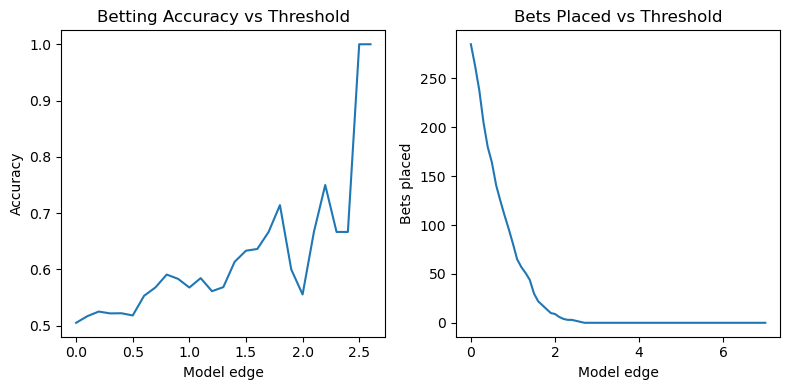

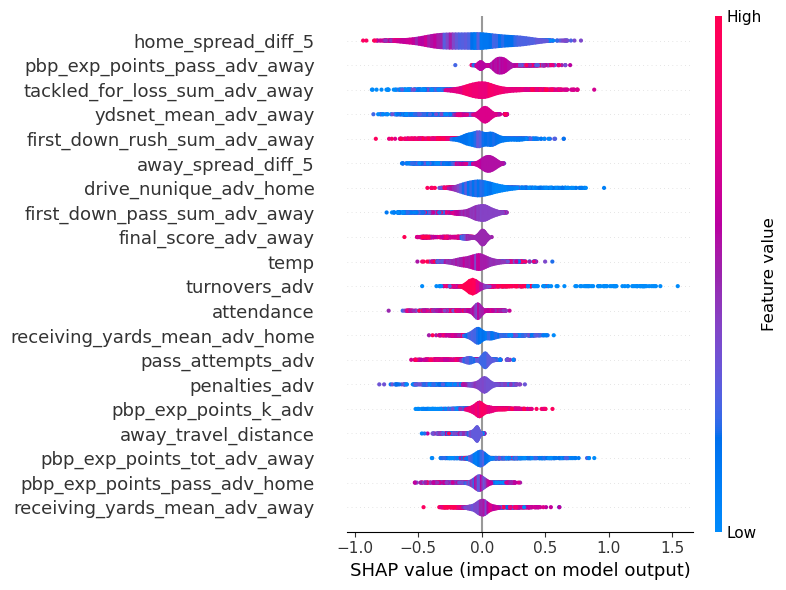

{'model_rmse': 12.632969742675321,
 'model_mae': 9.780532547700824,
 'model_r2': 0.2290533605346874,
 'vegas_rmse': 12.674224430405227,
 'vegas_mae': 9.829824561403509,
 'vegas_r2': 0.22400987581689857}

In [6]:
results = sweep_thresholds(df_test, 0, 7.1, .1)
plot_pipeline_results(df_test, results, model, df_train[features], shap_plot=True)
evaluate_model(df_test)

In [7]:
t = np.percentile(
    abs(df_train["home_line_inverse"] - df_train["model_predictions"]), 85
)
betting_simulation(df_test, t)

(22, 14)

In [8]:
df_test[["result", "home_line", "model_predictions"]].corr()

,result,home_line,model_predictions
result,1.000000,-0.490578,0.492724
home_line,-0.490578,1.000000,-0.987702
model_predictions,0.492724,-0.987702,1.000000
